<a href="https://colab.research.google.com/github/CarlosSotero/DeepLearning_CatvsDog/blob/main/Imagens_externas_Cat_vs_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📤 Faça o upload de uma imagem (jpg ou png):


Saving photo-1687993377657-f2fb8d53079e.jpg to photo-1687993377657-f2fb8d53079e (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Classe prevista: Gato 🐱
Confiança: 80.92%


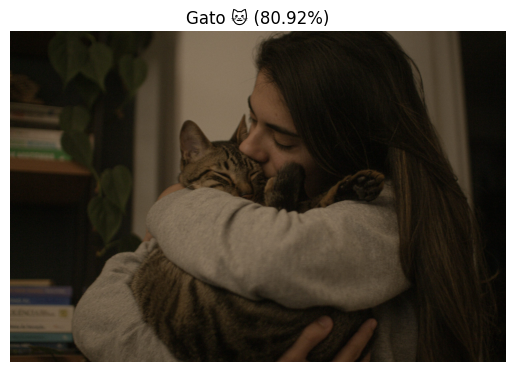

In [19]:
# Importando bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files
import io
from PIL import Image


from google.colab import drive
drive.mount('/content/drive')


# =========================
# CONFIGURAÇÕES
# =========================

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/Cópia de cat_vs_dog_v2.hdf5"

# =========================
# CARREGAR MODELO
# =========================

model = load_model(MODEL_PATH, compile=False)
IMG_SIZE = model.input_shape[1:3]

# =========================
# UPLOAD DA IMAGEM
# =========================

print("📤 Faça o upload de uma imagem (jpg ou png):")
uploaded = files.upload()

# Pega o nome do arquivo enviado
image_name = list(uploaded.keys())[0]

# Abre a imagem
img = Image.open(io.BytesIO(uploaded[image_name])).convert("RGB")
img_resized = img.resize(IMG_SIZE)

# =========================
# PREPROCESSAMENTO
# =========================

img_array = image.img_to_array(img_resized)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# =========================
# PREDIÇÃO
# =========================

prediction = model.predict(img_array)[0][0]

if prediction < 0.5:
    label = "Gato 🐱"
    confidence = 1 - prediction
else:
    label = "Cachorro 🐶"
    confidence = prediction

# =========================
# RESULTADOS
# =========================

print(f"\nClasse prevista: {label}")
print(f"Confiança: {confidence * 100:.2f}%")

# Alerta de baixa confiança
if 0.4 <= prediction <= 0.6:
    print("⚠️ Atenção: predição com baixa confiança")

# =========================
# VISUALIZAÇÃO
# =========================

plt.imshow(img)
plt.axis("off")
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.show()